In [ ]:
!pip install transformers sentence-transformers scikit-learn torch
!pip install gtts pydub
!pip install vosk
!pip install soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.1 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 83.7 MB/s eta 0:00:00
  Created wheel for srt: filename=srt-3.5.3-py3-none-any.whl size=22427 sha256=8b1b877f190c1417e6da4c8d0564a75dd1a8c7a68c548e532408de068b4e2222
  Stored in directory: /root/.cache/pip/wheels/7e/75/5b/e1d5c3756631e4bda806f6cc9640153b39484bb6f7b0b8def3
Successfully built srt


In [ ]:
import os
import wave
import json
from vosk import Model, KaldiRecognizer
from google.colab import files
from IPython.display import display, Javascript

# Function to pick the audio file manually
def upload_audio_file():
    uploaded = files.upload()
    for filename in uploaded.keys():
        return filename

# Display an alert box with the transcribed text
def alert(text):
    display(Javascript(f'alert("{text}")'))

# Download the model if you don't have it already
#!wget -P model 'https://alphacephei.com/vosk/models/vosk-model-small-en-us-0.15.zip'
#!unzip model/vosk-model-small-en-us-0.15.zip -d model

# Load the Vosk model
model = Model("model/vosk-model-small-en-us-0.15")

# Upload the audio file manually
audio_path = upload_audio_file()

# Ensure the file is in WAV format
if not audio_path.endswith('.wav'):
    print("Please upload a WAV file.")
else:
    # Open the audio file
    wf = wave.open(audio_path, "rb")

    # Initialize the recognizer
    rec = KaldiRecognizer(model, wf.getframerate())

    # Recognize speech from the audio file
    result = []
    while True:
        data = wf.readframes(4000)
        if len(data) == 0:
            break
        if rec.AcceptWaveform(data):
            result.append(json.loads(rec.Result()))

    result.append(json.loads(rec.FinalResult()))
    text = " ".join([r['text'] for r in result])

    # Display the transcribed text in an alert box
    alert(text)


--2025-11-07 09:13:04--  https://alphacephei.com/vosk/models/vosk-model-small-en-us-0.15.zip
Resolving alphacephei.com (alphacephei.com)... 188.40.21.16, 2a01:4f8:13a:279f::2
Connecting to alphacephei.com (alphacephei.com)|188.40.21.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 41205931 (39M) [application/zip]
Saving to: ‘model/vosk-model-small-en-us-0.15.zip’

vosk-model-small-en 100%[===================>]  39.30M  14.6MB/s    in 2.7s    

2025-11-07 09:13:07 (14.6 MB/s) - ‘model/vosk-model-small-en-us-0.15.zip’ saved [41205931/41205931]

Archive:  model/vosk-model-small-en-us-0.15.zip
   creating: model/vosk-model-small-en-us-0.15/
   creating: model/vosk-model-small-en-us-0.15/am/
  inflating: model/vosk-model-small-en-us-0.15/am/final.mdl  
   creating: model/vosk-model-small-en-us-0.15/graph/
  inflating: model/vosk-model-small-en-us-0.15/graph/disambig_tid.int  
  inflating: model/vosk-model-small-en-us-0.15/graph/HCLr.fst  
  inflating: model/vosk-

Saving P 2.wav to P 2.wav


<IPython.core.display.Javascript object>

In [ ]:
#HINDI Language
import os
import wave
import json
from vosk import Model, KaldiRecognizer
from google.colab import files
from IPython.display import display, Javascript

# Function to pick the audio file manually
def upload_audio_file():
    uploaded = files.upload()
    for filename in uploaded.keys():
        return filename

# Display an alert box with the transcribed text
def alert(text):
    display(Javascript(f'alert("{text}")'))

# Download the model if you don't have it already
#vosk-model-small-hi-0.22
!wget -P model 'https://alphacephei.com/vosk/models/vosk-model-small-hi-0.22.zip'
!unzip model/vosk-model-small-hi-0.22.zip -d model

# Load the Vosk model
#vosk-model-small-hi-0.22
model = Model("model/vosk-model-small-hi-0.22")

# Upload the audio file manually
audio_path = upload_audio_file()

# Ensure the file is in WAV format
if not audio_path.endswith('.wav'):
    print("Please upload a WAV file.")
else:
    # Open the audio file
    wf = wave.open(audio_path, "rb")

    # Initialize the recognizer
    rec = KaldiRecognizer(model, wf.getframerate())

    # Recognize speech from the audio file
    result = []
    while True:
        data = wf.readframes(4000)
        if len(data) == 0:
            break
        if rec.AcceptWaveform(data):
            result.append(json.loads(rec.Result()))

    result.append(json.loads(rec.FinalResult()))
    text = " ".join([r['text'] for r in result])

    # Display the transcribed text in an alert box
    alert(text)


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np

# Check for GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Step 1: User Symptom Input
user_input = """
I have a persistent dry cough, slight fever, sore throat, and fatigue for the past week.
There is also shortness of breath when walking up stairs.
"""

# Step 2: Knowledge Base of Symptom-Disease Pairs
symptom_disease_data = {
    "fever and cough with fatigue": "Influenza",
    "dry cough and shortness of breath": "COVID-19",
    "sore throat and fever": "Strep Throat",
    "fatigue and joint pain": "Rheumatoid Arthritis",
    "persistent cough and blood in sputum": "Tuberculosis",
    "shortness of breath and chest pain": "Pneumonia",
    "muscle ache and fever": "Dengue",
    "nausea and abdominal pain": "Gastroenteritis",
    "headache and sensitivity to light": "Meningitis",
    "sneezing, nasal congestion, and sore throat": "Common Cold",
    "abdominal bloating, pain, and diarrhea": "Irritable Bowel Syndrome",
    "frequent urination and thirst": "Diabetes Mellitus",
    "swollen lymph nodes, sore throat, and fever": "Mononucleosis",
    "high fever, chills, and sweating": "Malaria",
    "loss of smell and taste": "COVID-19"
}

kb_df = pd.DataFrame(symptom_disease_data.items(), columns=["Symptoms", "Disease"])

# Step 3: Load BioBERT Sentence Transformer
model = SentenceTransformer('pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb', device=device)

# Step 4: Encode Knowledge Base and User Input
kb_embeddings = model.encode(kb_df["Symptoms"].tolist(), convert_to_tensor=True)
user_embedding = model.encode(user_input, convert_to_tensor=True)

# Step 5: Compute Cosine Similarity
cos_scores = util.cos_sim(user_embedding, kb_embeddings)[0]
top_results = torch.topk(cos_scores, k=5)

print("\nTop Predicted Diseases Based on Input:\n")
for score, idx in zip(top_results[0], top_results[1]):
    idx = idx.item()  # Convert tensor index to int
    disease = kb_df.iloc[idx]["Disease"]
    matched_symptoms = kb_df.iloc[idx]["Symptoms"]
    print(f"Disease: {disease}")
    print(f"  ↳ Matched Symptom Pattern: {matched_symptoms}")
    print(f"  ↳ Similarity Score: {score.item():.4f}\n")

Using device: cuda

Top Predicted Diseases Based on Input:

Disease: COVID-19
  ↳ Matched Symptom Pattern: dry cough and shortness of breath
  ↳ Similarity Score: 0.6000

Disease: Influenza
  ↳ Matched Symptom Pattern: fever and cough with fatigue
  ↳ Similarity Score: 0.5588

Disease: Pneumonia
  ↳ Matched Symptom Pattern: shortness of breath and chest pain
  ↳ Similarity Score: 0.5155

Disease: Common Cold
  ↳ Matched Symptom Pattern: sneezing, nasal congestion, and sore throat
  ↳ Similarity Score: 0.4685

Disease: Irritable Bowel Syndrome
  ↳ Matched Symptom Pattern: abdominal bloating, pain, and diarrhea
  ↳ Similarity Score: 0.4272



In [ ]:
import os
import json
import zipfile

# Step 1: Write kaggle.json with your credentials
kaggle_credentials = {
    "username": "your_kaggle_username",        # ← Replace this
    "key": "your_kaggle_api_key"               # ← Replace this
}

# Save it to kaggle.json
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)

# Set file permission
os.chmod("/root/.kaggle/kaggle.json", 600)

# Step 2: Download dataset using Kaggle CLI
!kaggle datasets download -d bilal1907/mimic-iii-10k

# Step 3: Extract the ZIP file
with zipfile.ZipFile("mimic-iii-10k.zip", "r") as zip_ref:
    zip_ref.extractall("mimic-iii-10k")

print("✅ MIMIC-III 10k dataset downloaded and extracted to: mimic-iii-10k/")


Dataset URL: https://www.kaggle.com/datasets/bilal1907/mimic-iii-10k
License(s): MIT
✅ MIMIC-III 10k dataset downloaded and extracted to: mimic-iii-10k/


In [ ]:
import os

def list_files_and_folders(root_path):
    for dirpath, dirnames, filenames in os.walk(root_path):
        print(f"\n📁 Directory: {dirpath}")
        for dirname in dirnames:
            print(f"   📂 Subfolder: {dirname}")
        for filename in filenames:
            print(f"   📄 File: {filename}")

# Example usage
list_files_and_folders("mimic-iii-10k")  # Replace with your folder path



📁 Directory: mimic-iii-10k
   📂 Subfolder: MIMIC -III (10000 patients)

📁 Directory: mimic-iii-10k/MIMIC -III (10000 patients)
   📂 Subfolder: DATETIMEEVENTS
   📂 Subfolder: PRESCRIPTIONS
   📂 Subfolder: INPUTEVENTS_MV
   📂 Subfolder: D_LABITEMS
   📂 Subfolder: INPUTEVENTS_CV
   📂 Subfolder: D_ICD_DIAGNOSES
   📂 Subfolder: D_ICD_PROCEDURES
   📂 Subfolder: SERVICES
   📂 Subfolder: ADMISSIONS
   📂 Subfolder: DIAGNOSES_ICD
   📂 Subfolder: NOTEEVENTS
   📂 Subfolder: TRANSFERS
   📂 Subfolder: CAREGIVERS
   📂 Subfolder: PROCEDUREEVENTS_MV
   📂 Subfolder: LABEVENTS
   📂 Subfolder: CALLOUT
   📂 Subfolder: OUTPUTEVENTS
   📂 Subfolder: PROCEDURES_ICD
   📂 Subfolder: DRGCODES
   📂 Subfolder: ICUSTAYS
   📂 Subfolder: PATIENTS
   📂 Subfolder: D_ITEMS
   📂 Subfolder: MICROBIOLOGYEVENTS
   📂 Subfolder: CPTEVENTS
   📂 Subfolder: D_CPT

📁 Directory: mimic-iii-10k/MIMIC -III (10000 patients)/DATETIMEEVENTS
   📄 File: DATETIMEEVENTS_CV_random.csv
   📄 File: DATETIMEEVENTS_CV_sorted.csv

📁 Directory: mim

Using device: cuda

Top Predicted Diseases Based on Input:

Disease: Cough
  ↳ Similarity Score: 0.4396

Disease: Wheezing
  ↳ Similarity Score: 0.4338

Disease: Shortness of breath
  ↳ Similarity Score: 0.4293

Disease: Chronic pharyngitis
  ↳ Similarity Score: 0.4012

Disease: Other malaise and fatigue
  ↳ Similarity Score: 0.4006



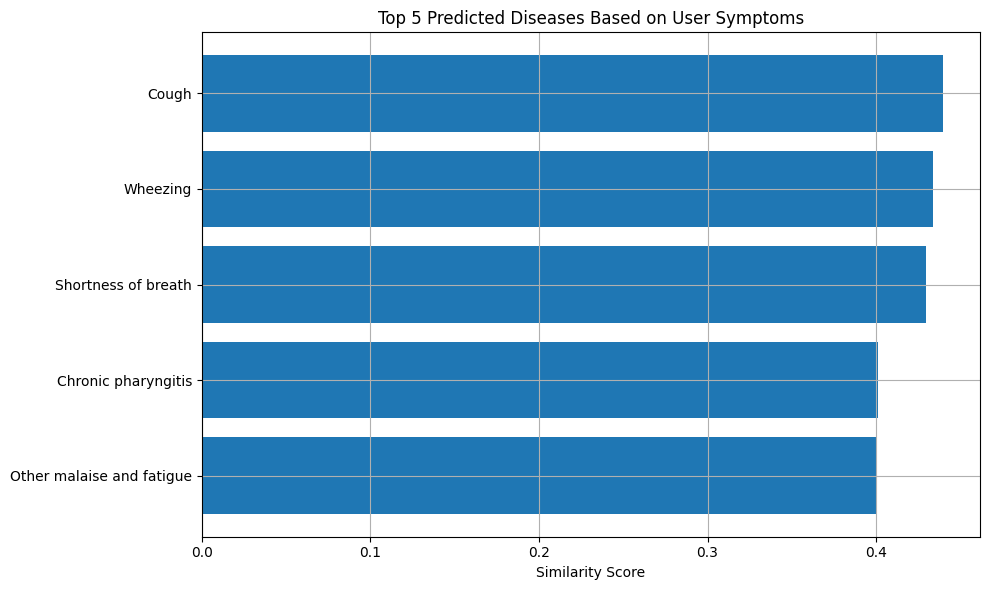


Best Matched Disease: Cough


In [ ]:
import torch
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import matplotlib.pyplot as plt

# Check for GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Step 1: User Symptom Input
user_input = """
I have a persistent dry cough, slight fever, sore throat, and fatigue for the past week.
There is also shortness of breath when walking up stairs.
"""

# Step 2: Load MIMIC-III Diagnosis Descriptions
diagnoses_df = pd.read_csv(
    "mimic-iii-10k/MIMIC -III (10000 patients)/D_ICD_DIAGNOSES/D_ICD_DIAGNOSES.csv"
)

# Keep only ICD code and long title for descriptions
diagnoses_df = diagnoses_df[['ICD9_CODE', 'LONG_TITLE']].dropna()
diagnoses_df = diagnoses_df.drop_duplicates(subset='LONG_TITLE')
diagnoses_df = diagnoses_df.reset_index(drop=True)

# Step 3: Load BioBERT Sentence Transformer
model = SentenceTransformer('pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb', device=device)

# Step 4: Encode Knowledge Base and User Input
kb_embeddings = model.encode(diagnoses_df["LONG_TITLE"].tolist(), convert_to_tensor=True)
user_embedding = model.encode(user_input, convert_to_tensor=True)

# Step 5: Compute Cosine Similarity
cos_scores = util.cos_sim(user_embedding, kb_embeddings)[0]
top_results = torch.topk(cos_scores, k=5)

# Prepare results for display and plotting
results = []
print("\nTop Predicted Diseases Based on Input:\n")
for score, idx in zip(top_results[0], top_results[1]):
    idx = idx.item()
    disease = diagnoses_df.iloc[idx]["LONG_TITLE"]
    similarity = score.item()
    results.append((disease, similarity))
    print(f"Disease: {disease}")
    print(f"  ↳ Similarity Score: {similarity:.4f}\n")

# Step 6: Plot Top Matches
diseases, scores = zip(*results)
plt.figure(figsize=(10, 6))
plt.barh(diseases[::-1], scores[::-1])
plt.xlabel("Similarity Score")
plt.title("Top 5 Predicted Diseases Based on User Symptoms")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Final Output - Best Matched Disease
best_match = results[0][0]
print(f"\nBest Matched Disease: {best_match}")

Using device: cpu


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]


Top Predicted Diseases Based on Input:

Disease: chronic migraine without aura, with intractable migraine, so stated, without mention of status migrainosus
  ↳ Similarity Score: 0.8834

Disease: menstrual migraine, with intractable migraine, so stated, without mention of status migrainosus
  ↳ Similarity Score: 0.8782

Disease: migraine without aura, with intractable migraine, so stated, without mention of status migrainosus
  ↳ Similarity Score: 0.8751

Disease: chronic migraine without aura, without mention of intractable migraine with status migrainosus
  ↳ Similarity Score: 0.8750

Disease: dizziness and giddiness
  ↳ Similarity Score: 0.8750



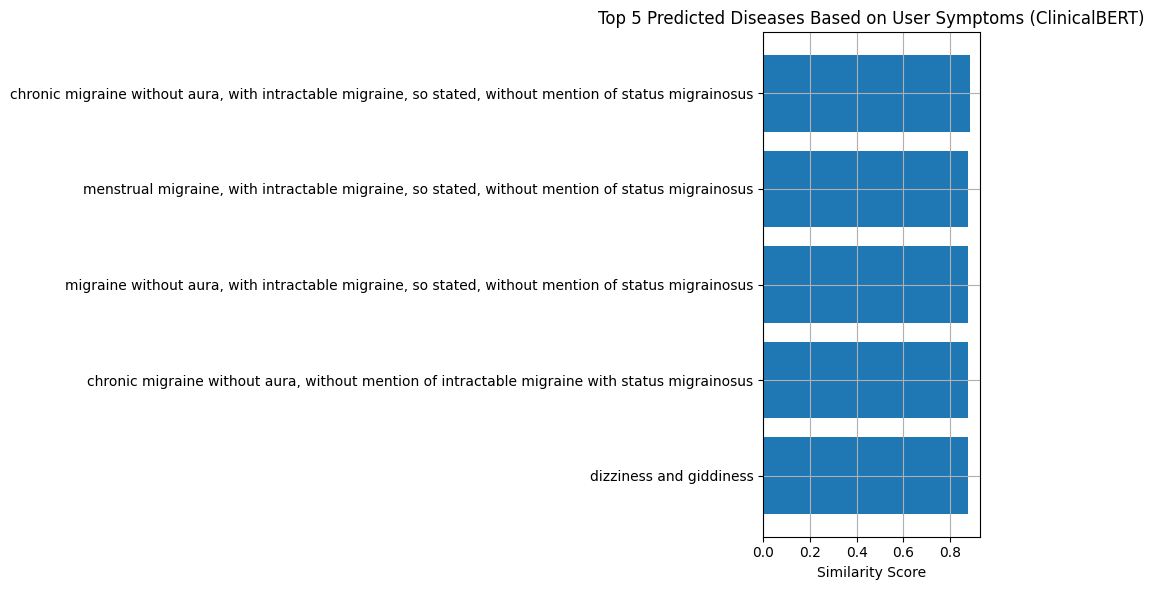


Best Matched Disease: chronic migraine without aura, with intractable migraine, so stated, without mention of status migrainosus


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, models, util
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Force CPU for reliability
device = 'cpu'
print(f"Using device: {device}")

# Step 2: User Symptom Input
user_input = """
I have a persistent dry cough, slight fever, sore throat, and fatigue for the past week.
There is also shortness of breath when walking up stairs.
"""

# Step 3: Load MIMIC-III Diagnosis Descriptions
diagnoses_df = pd.read_csv(
    "mimic-iii-10k/MIMIC -III (10000 patients)/D_ICD_DIAGNOSES/D_ICD_DIAGNOSES.csv"
)

# Step 4: Preprocess Diagnosis Titles
diagnoses_df = diagnoses_df[['ICD9_CODE', 'LONG_TITLE']].dropna()
diagnoses_df["LONG_TITLE"] = diagnoses_df["LONG_TITLE"].str.lower().str.strip()
diagnoses_df = diagnoses_df[diagnoses_df["LONG_TITLE"].str.len() > 15]
diagnoses_df = diagnoses_df.drop_duplicates(subset="LONG_TITLE").reset_index(drop=True)

# Step 5: Load ClinicalBERT Model
word_embedding_model = models.Transformer('emilyalsentzer/Bio_ClinicalBERT')
pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())
model = SentenceTransformer(modules=[word_embedding_model, pooling_model], device=device)

# Step 6: Encode Diagnosis Titles and User Input
kb_embeddings = model.encode(diagnoses_df["LONG_TITLE"].tolist(), convert_to_tensor=True)
user_embedding = model.encode(user_input, convert_to_tensor=True)

# Step 7: Compute Similarity Scores
cos_scores = util.cos_sim(user_embedding, kb_embeddings)[0]
top_results = torch.topk(cos_scores, k=5)

# Step 8: Display Results and Prepare for Plot
results = []
print("\nTop Predicted Diseases Based on Input:\n")
for score, idx in zip(top_results[0], top_results[1]):
    idx = idx.item()
    disease = diagnoses_df.iloc[idx]["LONG_TITLE"]
    similarity = score.item()
    results.append((disease, similarity))
    print(f"Disease: {disease}")
    print(f"  ↳ Similarity Score: {similarity:.4f}\n")

# Step 9: Plot Results
diseases, scores = zip(*results)
plt.figure(figsize=(10, 6))
plt.barh(diseases[::-1], scores[::-1])
plt.xlabel("Similarity Score")
plt.title("Top 5 Predicted Diseases Based on User Symptoms (ClinicalBERT)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 10: Final Output - Best Match
best_match = results[0][0]
print(f"\nBest Matched Disease: {best_match}")


In [ ]:
#HINDI Language
import os
import wave
import json
from vosk import Model, KaldiRecognizer
from google.colab import files
from IPython.display import display, Javascript
import torch
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, models, util
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Force CPU for reliability
device = 'cpu'
print(f"Using device: {device}")


# Function to pick the audio file manually
def upload_audio_file():
    uploaded = files.upload()
    for filename in uploaded.keys():
        return filename

# Display an alert box with the transcribed text
def alert(text):
    display(Javascript(f'alert("{text}")'))

# Download the model if you don't have it already
#vosk-model-small-hi-0.22
!wget -P model 'https://alphacephei.com/vosk/models/vosk-model-small-hi-0.22.zip'
!unzip model/vosk-model-small-hi-0.22.zip -d model

# Load the Vosk model
#vosk-model-small-hi-0.22
model = Model("model/vosk-model-small-hi-0.22")

# Upload the audio file manually
audio_path = upload_audio_file()

# Ensure the file is in WAV format
if not audio_path.endswith('.wav'):
    print("Please upload a WAV file.")
else:
    # Open the audio file
    wf = wave.open(audio_path, "rb")

    # Initialize the recognizer
    rec = KaldiRecognizer(model, wf.getframerate())

    # Recognize speech from the audio file
    result = []
    while True:
        data = wf.readframes(4000)
        if len(data) == 0:
            break
        if rec.AcceptWaveform(data):
            result.append(json.loads(rec.Result()))

    result.append(json.loads(rec.FinalResult()))
    text = " ".join([r['text'] for r in result])

    # Display the transcribed text in an alert box
    alert(text)
    # Step 2: User Symptom Input
    from transformers import MarianMTModel, MarianTokenizer

    translation_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-hi-en")
    translation_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-hi-en")

    translated_input = translation_tokenizer.prepare_seq2seq_batch([text], return_tensors="pt")
    translated_output = translation_model.generate(**translated_input)
    translated_text = translation_tokenizer.batch_decode(translated_output, skip_special_tokens=True)[0]

    user_input = translated_text
    alert(translated_text)


    # Step 3: Load MIMIC-III Diagnosis Descriptions
    diagnoses_df = pd.read_csv(
        "mimic-iii-10k/MIMIC -III (10000 patients)/D_ICD_DIAGNOSES/D_ICD_DIAGNOSES.csv"
    )

    # Step 4: Preprocess Diagnosis Titles
    diagnoses_df = diagnoses_df[['ICD9_CODE', 'LONG_TITLE']].dropna()
    diagnoses_df["LONG_TITLE"] = diagnoses_df["LONG_TITLE"].str.lower().str.strip()
    diagnoses_df = diagnoses_df[diagnoses_df["LONG_TITLE"].str.len() > 15]
    diagnoses_df = diagnoses_df.drop_duplicates(subset="LONG_TITLE").reset_index(drop=True)

    # Step 5: Load ClinicalBERT Model
    word_embedding_model = models.Transformer('emilyalsentzer/Bio_ClinicalBERT')
    pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())
    model = SentenceTransformer(modules=[word_embedding_model, pooling_model], device=device)

    # Step 6: Encode Diagnosis Titles and User Input
    kb_embeddings = model.encode(diagnoses_df["LONG_TITLE"].tolist(), convert_to_tensor=True)
    user_embedding = model.encode(user_input, convert_to_tensor=True)

    # Step 7: Compute Similarity Scores
    cos_scores = util.cos_sim(user_embedding, kb_embeddings)[0]
    top_results = torch.topk(cos_scores, k=5)

    # Step 8: Display Results and Prepare for Plot
    results = []
    print("\nTop Predicted Diseases Based on Input:\n")
    for score, idx in zip(top_results[0], top_results[1]):
        idx = idx.item()
        disease = diagnoses_df.iloc[idx]["LONG_TITLE"]
        similarity = score.item()
        results.append((disease, similarity))
        print(f"Disease: {disease}")
        print(f"  ↳ Similarity Score: {similarity:.4f}\n")

    # Step 9: Plot Results
    diseases, scores = zip(*results)
    plt.figure(figsize=(10, 6))
    plt.barh(diseases[::-1], scores[::-1])
    plt.xlabel("Similarity Score")
    plt.title("Top 5 Predicted Diseases Based on User Symptoms (ClinicalBERT)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Step 10: Final Output - Best Match
    best_match = results[0][0]
    print(f"\nBest Matched Disease: {best_match}")



In [ ]:
!pip install git+https://github.com/openai/whisper.git
!sudo apt-get install ffmpeg
from google.colab import files
import whisper

import os
import wave
import json
from vosk import Model, KaldiRecognizer
from google.colab import files
from IPython.display import display, Javascript
import torch
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer, models, util
import pandas as pd
import matplotlib.pyplot as plt

import os
import json
import zipfile

# Step 1: Write kaggle.json with your credentials
kaggle_credentials = {
    "username": "your_kaggle_username",        # ← Replace this
    "key": "your_kaggle_api_key"               # ← Replace this
}

# Save it to kaggle.json
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)

# Set file permission
os.chmod("/root/.kaggle/kaggle.json", 600)

# Step 2: Download dataset using Kaggle CLI
!kaggle datasets download -d bilal1907/mimic-iii-10k

# Step 3: Extract the ZIP file
with zipfile.ZipFile("mimic-iii-10k.zip", "r") as zip_ref:
    zip_ref.extractall("mimic-iii-10k")

print("✅ MIMIC-III 10k dataset downloaded and extracted to: mimic-iii-10k/")

# Upload audio file manually
print("Please upload your audio file:")
uploaded = files.upload()

# Get the uploaded filename
audio_path = list(uploaded.keys())[0]
print(f"Uploaded file: {audio_path}")

# Load the Whisper model (choose from: tiny, base, small, medium, large)
model = whisper.load_model("small")

# Transcribe the uploaded file (forcing Hindi language)
result = model.transcribe(audio_path, language="hi")

# Display the result
print("\nTranscribed Hindi Text:\n")
print(result["text"])
text = result["text"]
from transformers import MarianMTModel, MarianTokenizer
translation_tokenizer = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-hi-en")
translation_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-hi-en")

translated_input = translation_tokenizer.prepare_seq2seq_batch([text], return_tensors="pt")
translated_output = translation_model.generate(**translated_input)
translated_text = translation_tokenizer.batch_decode(translated_output, skip_special_tokens=True)[0]

user_input = translated_text
alert(translated_text)


# Step 3: Load MIMIC-III Diagnosis Descriptions
diagnoses_df = pd.read_csv(
    "mimic-iii-10k/MIMIC -III (10000 patients)/D_ICD_DIAGNOSES/D_ICD_DIAGNOSES.csv"
)

# Step 4: Preprocess Diagnosis Titles
diagnoses_df = diagnoses_df[['ICD9_CODE', 'LONG_TITLE']].dropna()
diagnoses_df["LONG_TITLE"] = diagnoses_df["LONG_TITLE"].str.lower().str.strip()
diagnoses_df = diagnoses_df[diagnoses_df["LONG_TITLE"].str.len() > 15]
diagnoses_df = diagnoses_df.drop_duplicates(subset="LONG_TITLE").reset_index(drop=True)

# Step 5: Load ClinicalBERT Model
word_embedding_model = models.Transformer('emilyalsentzer/Bio_ClinicalBERT')
pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())
model = SentenceTransformer(modules=[word_embedding_model, pooling_model], device=device)

# Step 6: Encode Diagnosis Titles and User Input
kb_embeddings = model.encode(diagnoses_df["LONG_TITLE"].tolist(), convert_to_tensor=True)
user_embedding = model.encode(user_input, convert_to_tensor=True)

# Step 7: Compute Similarity Scores
cos_scores = util.cos_sim(user_embedding, kb_embeddings)[0]
top_results = torch.topk(cos_scores, k=5)

# Step 8: Display Results and Prepare for Plot
results = []
print("\nTop Predicted Diseases Based on Input:\n")
for score, idx in zip(top_results[0], top_results[1]):
    idx = idx.item()
    disease = diagnoses_df.iloc[idx]["LONG_TITLE"]
    similarity = score.item()
    results.append((disease, similarity))
    print(f"Disease: {disease}")
    print(f"  ↳ Similarity Score: {similarity:.4f}\n")

# Step 9: Plot Results
diseases, scores = zip(*results)
plt.figure(figsize=(10, 6))
plt.barh(diseases[::-1], scores[::-1])
plt.xlabel("Similarity Score")
plt.title("Top 5 Predicted Diseases Based on User Symptoms (ClinicalBERT)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 10: Final Output - Best Match
best_match = results[0][0]
print(f"\nBest Matched Disease: {best_match}")

  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-dgn_53z7
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-dgn_53z7
  Resolved https://github.com/openai/whisper.git to commit c0d2f624c09dc18e709e37c2ad90c039a4eb72a2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
Dataset URL: https://www.kaggle.com/datasets/bilal1907/mimic-iii-10k
License(s): MIT
100% 1.12G/1.12G [01:26<00:00, 16.5MB/s]
100% 1.12G/1.12G [01:26<00:00, 14.0MB/s]


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Using device: cuda
📤 Please upload your audio file (WAV/MP3/M4A/FLAC):


Saving conversation_1.mp3 to conversation_1.mp3
✅ Uploaded: conversation_1.mp3

📝 Hindi Transcription:
 तोक्तर, आप आप बई फीलिं वेरी ताएर्ड लेएगा आप शीए, आप आप आप आप आप आप बई फीलिं फीलिं वेशावाई

🌐 Translated to English (NLLB):
 Tokater, you're gonna take you by the way, you're gonna take you by the way, you're gonna take you by the way, you're gonna take you by the way, you're gonna take you by the way, you're gonna take you by the way, you're gonna take you by the way, you're gonna take you by the way, you're gonna take you by the way, you're gonna take you by the way, you're gonna take you by the way, you're gonna take you by the way
Dataset URL: https://www.kaggle.com/datasets/bilal1907/mimic-iii-10k
License(s): MIT
✅ MIMIC-III 10k dataset downloaded and extracted
✅ Loaded 14039 diagnosis titles


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Batches:   0%|          | 0/439 [00:00<?, ?it/s]


🔍 Top Predicted Diseases:

Disease: other multiple birth (three or more), mates liveborn and stillborn, born outside hospital and not hospitalized
  ↳ Similarity Score: 0.6545

Disease: other multiple birth (three or more), unspecified whether mates liveborn or stillborn, born outside of hospital
  ↳ Similarity Score: 0.6502

Disease: burn [any degree] involving 90 percent or more of body surface with third degree burn, 90% or more of body surface
  ↳ Similarity Score: 0.6501

Disease: other multiple birth (three or more), mates all stillborn, born outside of hospital and not hospitalized
  ↳ Similarity Score: 0.6482

Disease: other multiple birth (three or more), mates all liveborn, born outside hospital and not hospitalized
  ↳ Similarity Score: 0.6427



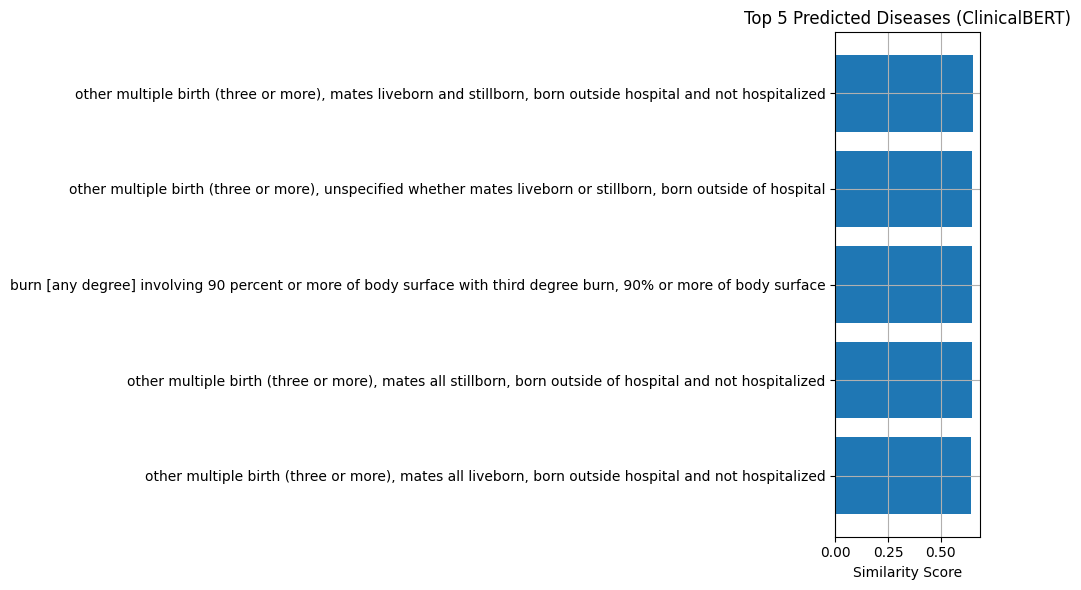


🏥 Best Matched Disease: other multiple birth (three or more), mates liveborn and stillborn, born outside hospital and not hospitalized


In [ ]:
# ===================== INSTALL DEPENDENCIES =====================
!pip -q install git+https://github.com/openai/whisper.git
!pip -q install sentence-transformers transformers kaggle
!sudo apt-get -y install ffmpeg > /dev/null

# ===================== SUPPRESS WARNINGS =====================
import warnings
warnings.filterwarnings("ignore")

# ===================== SET DEVICE (GPU or CPU) =====================
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {device}")

# ===================== UPLOAD AUDIO FILE =====================
from google.colab import files
print("📤 Please upload your audio file (WAV/MP3/M4A/FLAC):")
uploaded = files.upload()
audio_path = list(uploaded.keys())[0]
print(f"✅ Uploaded: {audio_path}")

# ===================== TRANSCRIBE HINDI AUDIO USING WHISPER =====================
import whisper

whisper_model = whisper.load_model("small", device=device)
whisper_result = whisper_model.transcribe(audio_path, language="hi")
hindi_text = (whisper_result.get("text") or "").strip()

print("\n📝 Hindi Transcription:\n", hindi_text)

# ===================== TRANSLATE HINDI TO ENGLISH (NLLB FIXED) =====================
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import re

model_name = "facebook/nllb-200-distilled-600M"
nllb_tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
nllb_model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

src_lang = "hin_Deva"
tgt_lang = "eng_Latn"

def nllb_translate_hi_to_en(text: str, sentence_wise: bool = True) -> str:
    text = (text or "").strip()
    if not text:
        return ""

    # Robust target language BOS token id
    forced_bos_token_id = nllb_tokenizer.convert_tokens_to_ids(tgt_lang)
    if forced_bos_token_id is None or forced_bos_token_id == nllb_tokenizer.unk_token_id:
        forced_bos_token_id = nllb_model.config.lang_code_to_id[tgt_lang]

    chunks = [text]
    if sentence_wise:
        chunks = [s.strip() for s in re.split(r"[।?!\.]\s*", text) if s.strip()]
        if not chunks:
            chunks = [text]

    outputs = []
    with torch.no_grad():
        for chunk in chunks:
            nllb_tokenizer.src_lang = src_lang
            inputs = nllb_tokenizer(
                chunk,
                return_tensors="pt",
                truncation=True,
                max_length=256 if sentence_wise else 512,
                padding=True
            ).to(device)

            out = nllb_model.generate(
                **inputs,
                forced_bos_token_id=forced_bos_token_id,
                num_beams=4,
                max_length=256 if sentence_wise else 512
            )
            outputs.append(nllb_tokenizer.batch_decode(out, skip_special_tokens=True)[0])

    return " ".join(o.strip() for o in outputs if o and o.strip()).strip()

english_text = nllb_translate_hi_to_en(hindi_text, sentence_wise=True)
print("\n🌐 Translated to English (NLLB):\n", english_text)

# ===================== SETUP KAGGLE CREDENTIALS =====================
import os, json, zipfile

kaggle_credentials = {
    "username": "your_kaggle_username",   # 🔁 Replace this
    "key": "your_kaggle_api_key"          # 🔁 Replace this
}
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 600)

# ===================== DOWNLOAD & EXTRACT MIMIC-III 10K =====================
!kaggle datasets download -d bilal1907/mimic-iii-10k -q
with zipfile.ZipFile("mimic-iii-10k.zip", "r") as zip_ref:
    zip_ref.extractall("mimic-iii-10k")
print("✅ MIMIC-III 10k dataset downloaded and extracted")

# ===================== LOAD DIAGNOSIS DATA =====================
import pandas as pd

diag_path = "mimic-iii-10k/MIMIC -III (10000 patients)/D_ICD_DIAGNOSES/D_ICD_DIAGNOSES.csv"
diagnoses_df = pd.read_csv(diag_path)

diagnoses_df = diagnoses_df[['ICD9_CODE', 'LONG_TITLE']].dropna()
diagnoses_df["LONG_TITLE"] = diagnoses_df["LONG_TITLE"].astype(str).str.lower().str.strip()
diagnoses_df = diagnoses_df[diagnoses_df["LONG_TITLE"].str.len() > 15]
diagnoses_df = diagnoses_df.drop_duplicates(subset="LONG_TITLE").reset_index(drop=True)

print(f"✅ Loaded {len(diagnoses_df)} diagnosis titles")

# ===================== CLINICALBERT EMBEDDINGS (FIXED) =====================
from sentence_transformers import SentenceTransformer, models, util

# IMPORTANT FIX: do NOT pass device= to models.Transformer
word_embedding_model = models.Transformer("emilyalsentzer/Bio_ClinicalBERT")
pooling_model = models.Pooling(word_embedding_model.get_word_embedding_dimension())
clinical_model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

# Move SentenceTransformer to GPU/CPU
clinical_model = clinical_model.to(device)

kb_embeddings = clinical_model.encode(diagnoses_df["LONG_TITLE"].tolist(), convert_to_tensor=True, show_progress_bar=True)
user_embedding = clinical_model.encode(english_text if english_text else "no symptoms provided", convert_to_tensor=True)

# ===================== CALCULATE SIMILARITIES =====================
cos_scores = util.cos_sim(user_embedding, kb_embeddings)[0]
top_results = torch.topk(cos_scores, k=5)

# ===================== DISPLAY RESULTS =====================
results = []
print("\n🔍 Top Predicted Diseases:\n")
for score, idx in zip(top_results[0], top_results[1]):
    idx = idx.item()
    disease = diagnoses_df.iloc[idx]["LONG_TITLE"]
    similarity = float(score.item())
    results.append((disease, similarity))
    print(f"Disease: {disease}\n  ↳ Similarity Score: {similarity:.4f}\n")

# ===================== PLOT TOP MATCHES =====================
import matplotlib.pyplot as plt

diseases, scores = zip(*results)
plt.figure(figsize=(10, 6))
plt.barh(diseases[::-1], scores[::-1])
plt.xlabel("Similarity Score")
plt.title("Top 5 Predicted Diseases (ClinicalBERT)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ===================== FINAL OUTPUT =====================
best_match = results[0][0]
print(f"\n🏥 Best Matched Disease: {best_match}")
